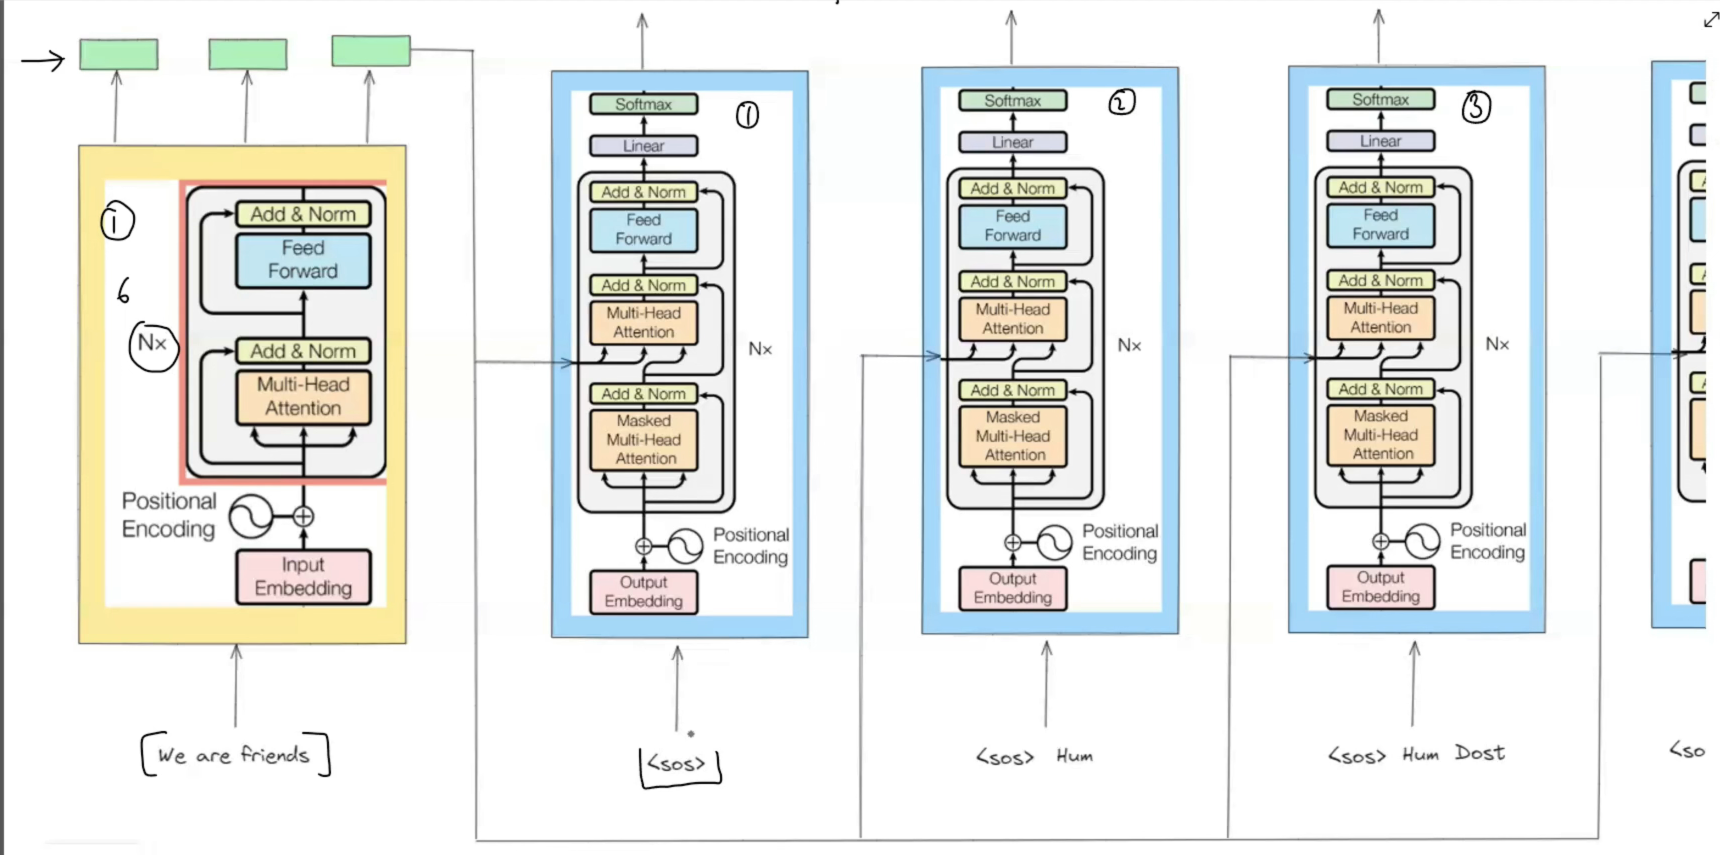

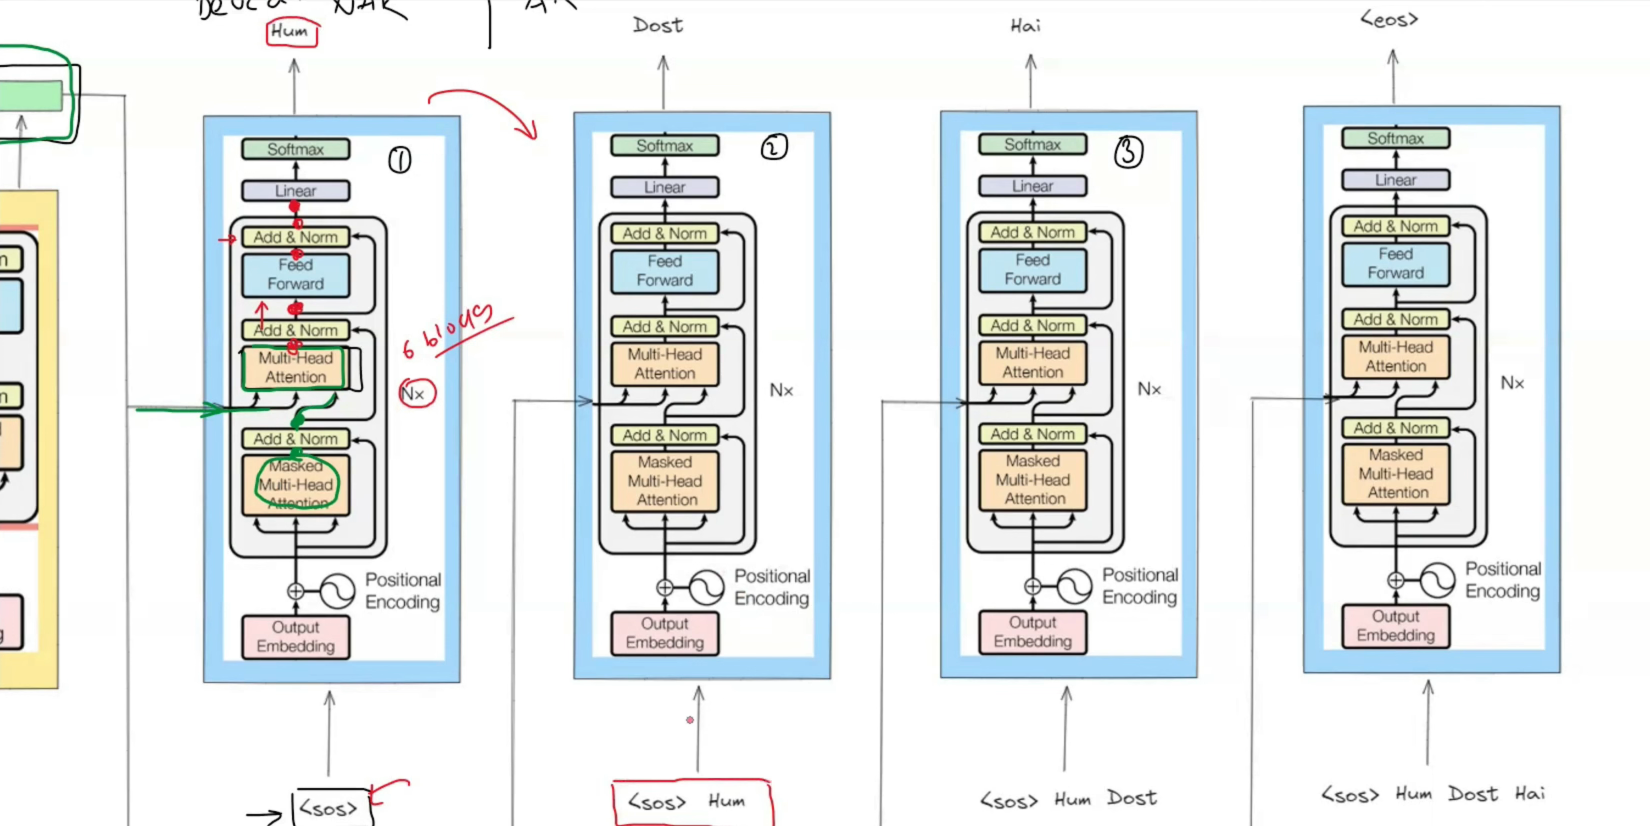

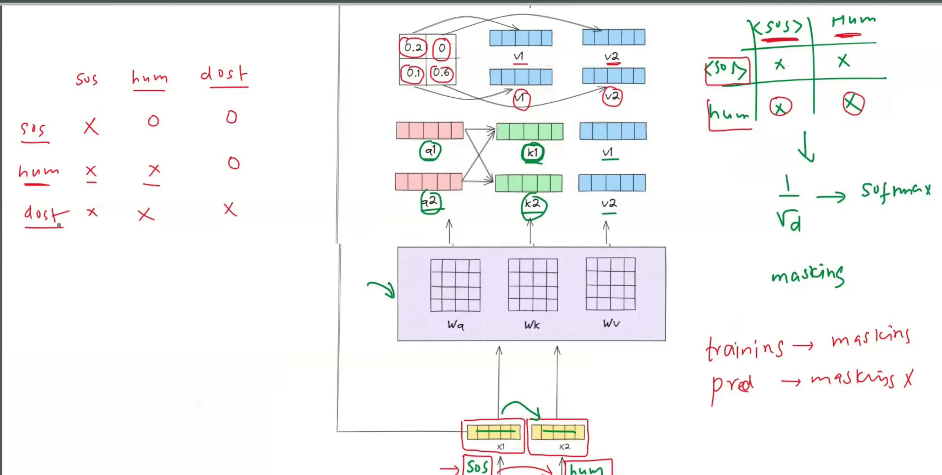

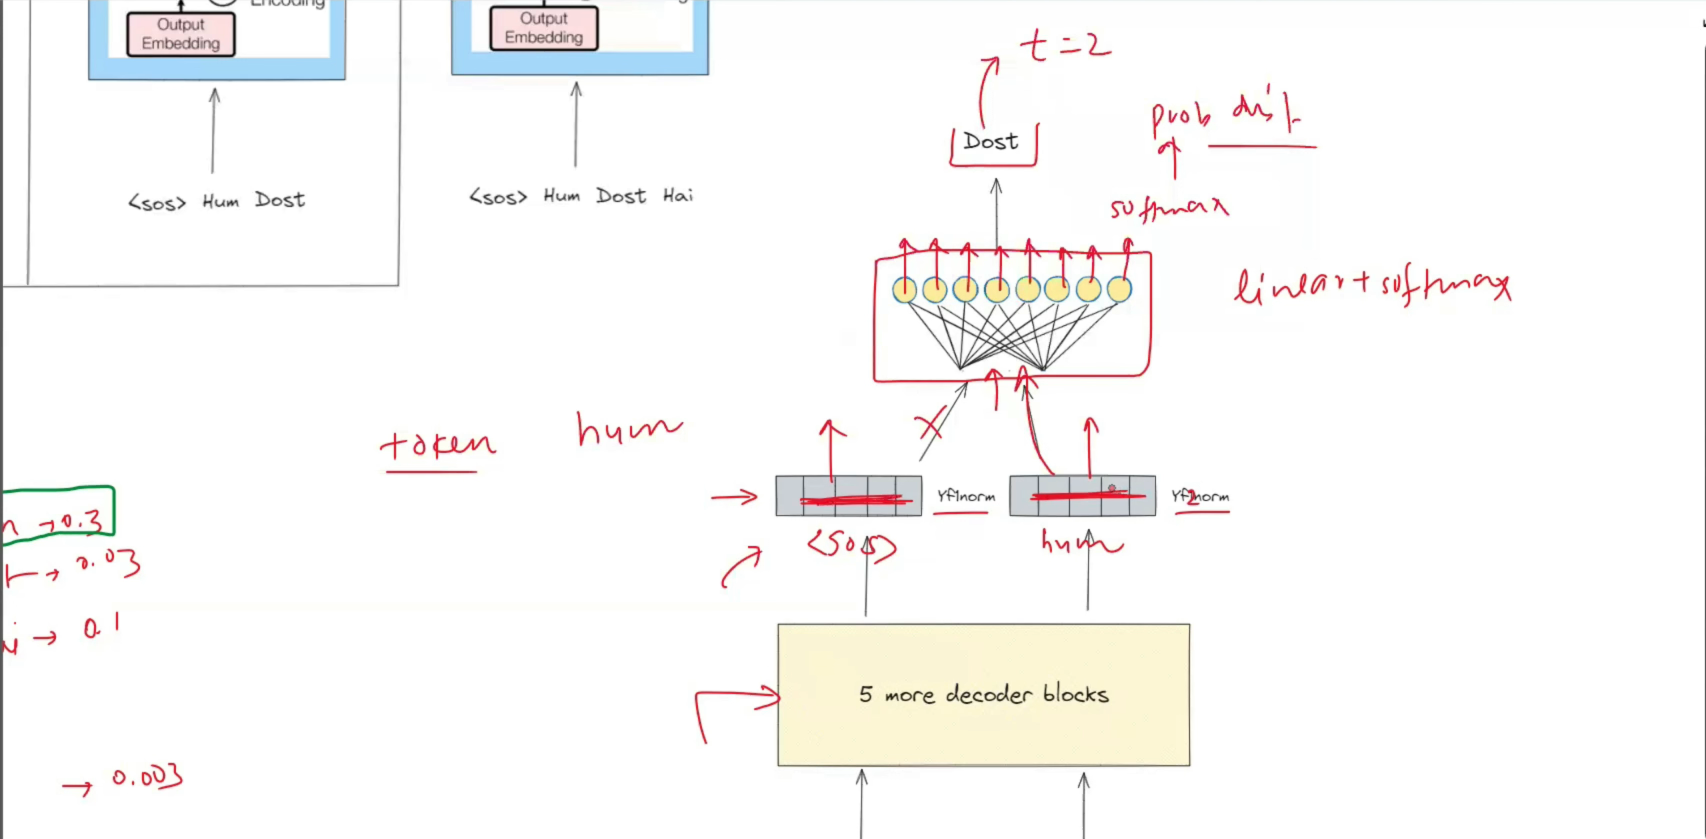

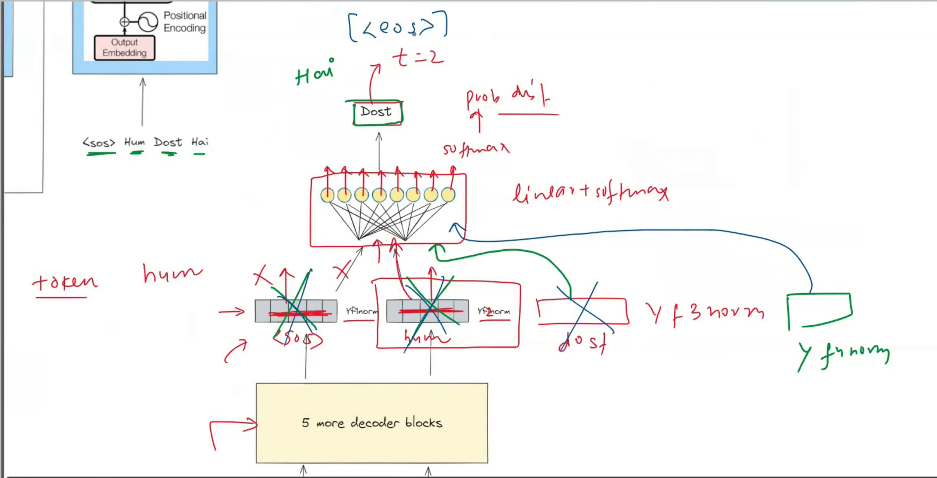



### Summary of Transformer Inference

The core difference between the training and inference stages of a Transformer architecture lies primarily in the **decoder's behavior**.

1.  **Encoder Behavior:** During both training and inference, the encoder part of the Transformer behaves exactly the same way. There is no change in its functioning. Its purpose is to process the input sentence and convert it into contextualized numerical representations (context vectors).
2.  **Decoder Behavior:** This is where the main difference occurs.
    *   **During Training:** The decoder operates in a non-auto-regressive manner. Since the entire target (output) sentence is known during training, all its words can be fed into the decoder simultaneously for parallel processing.
    *   **During Inference (Prediction):** The decoder behaves in an **auto-regressive** manner. The output sentence is not known; it needs to be predicted word by word, step by step. In each time step, the decoder predicts one word, and this newly predicted word is then fed back as input for the next prediction step, along with previous tokens.
3.  **Masking:** Masking, which prevents a token from attending to future tokens, is crucial and **always applied during inference** in the self-attention block of the decoder. This is because the training process used masking, and removing it during inference would introduce a data shift, impacting prediction quality.
4.  **Increasing Input Sequence:** In each subsequent step of inference, the input to the decoder grows as the newly predicted token is added to the sequence of previously seen tokens.
5.  **Output Selection:** At each prediction step, even though multiple token representations are processed through the decoder blocks, **only the representation corresponding to the last token in the input sequence** is used by the final linear and softmax layers to generate the next word.

### Step-wise Process of Transformer Inference (Example: English to Hindi Translation)

Let's consider the task of translating the English sentence "We are friends" into Hindi using a pre-trained Transformer model.

**Setup:** A Transformer model has been trained on a large dataset of English-Hindi sentence pairs and is ready to make predictions.

**Phase 1: Encoder Processing**
1.  **Input to Encoder:** The English sentence "We are friends" is fed into the encoder.
2.  **Tokenization & Embedding:** The sentence is tokenized into individual words ("We", "are", "friends"). Each token is converted into a numerical embedding vector.
3.  **Positional Encoding:** Positional encodings are added to the embeddings to provide information about the order of words in the sentence.
4.  **Multi-Head Attention & Feed-Forward Networks:** The tokens pass through multiple layers (typically six) of multi-head attention blocks (to capture context) and feed-forward neural networks (for non-linear transformations). Add & Normalize layers are applied between these blocks.
5.  **Encoder Output:** The final output of the encoder is a set of **context vectors** for each input token (e.g., for "We," "are," "friends"), which represent the Transformer's understanding of the English sentence. These vectors capture the contextual relationships between the words.

**Phase 2: Decoder Processing (Auto-regressive Word Generation)**

The decoder's job is to generate the Hindi translation one word at a time, using the encoder's output and the words it has already predicted.

**Step 1: Predict the First Hindi Word ("हम" - "Hum")**
1.  **Initial Decoder Input:** To start the decoding process, a special **Start of Sentence (SOS)** token is sent into the decoder.
2.  **Embedding & Positional Encoding:** The SOS token is embedded into a vector (x1) and combined with its positional encoding.
3.  **Masked Self-Attention Block:**
    *   The input vector (x1) is used to generate query (Q), key (K), and value (V) vectors.
    *   Attention scores are computed for SOS attending to itself (since it's the only token so far).
    *   **Masking:** Even with a single token, masking is conceptually applied, ensuring no future tokens are "seen".
    *   The attention scores are multiplied by the value vectors to produce a context vector (z1) for the SOS token.
4.  **Add & Normalize:** The z1 vector is added to the initial input x1 (residual connection) and then normalized to produce z1_norm.
5.  **Cross-Attention Block:**
    *   This block calculates attention between the decoder's current representation (z1_norm from SOS) and the **encoder's output context vectors** ("We," "are," "friends").
    *   Queries (Q) are derived from the decoder's z1_norm.
    *   Keys (K) and Values (V) are derived from the encoder's output vectors.
    *   Attention scores are computed to determine how much the SOS token relates to each word in the English sentence.
    *   These scores are used to weight and combine the encoder's value vectors, producing a cross-attention output vector (zC1).
6.  **Add & Normalize:** The zC1 vector is added to z1_norm (residual connection) and then normalized to produce zC1_norm.
7.  **Feed-Forward Network:** The zC1_norm vector passes through a feed-forward neural network for further non-linear processing, resulting in y1.
8.  **Add & Normalize:** The y1 vector is added to zC1_norm (residual connection) and normalized to yield y1_norm.
9.  **Repeat for Multiple Decoder Blocks:** This entire sequence (Masked Self-Attention, Cross-Attention, Feed-Forward, with Add & Norm layers) is repeated for all six decoder blocks. The y1_norm from one block becomes the input to the next. The final output from the sixth decoder block is yF1_norm.
10. **Linear and Softmax Layers:** The final vector yF1_norm is passed through a linear layer and then a softmax activation function. This produces a probability distribution over the entire Hindi vocabulary.
11. **Prediction:** The word with the highest probability is selected as the first output word. In our example, let's say it's **"हम"**.

**Step 2: Predict the Second Hindi Word ("दोस्त" - "Dost")**
1.  **Updated Decoder Input:** The input for the second step now consists of **SOS and the newly predicted word "हम"**.
2.  **Embedding & Positional Encoding:** Both SOS and "हम" are embedded and positionally encoded, resulting in two input vectors, x1 (for SOS) and x2 (for "हम").
3.  **Masked Self-Attention Block:**
    *   Q, K, V vectors are calculated for both x1 and x2.
    *   Attention scores are computed for all pairwise interactions (SOS-SOS, SOS-हम, हम-SOS, हम-हम).
    *   **Crucial Masking:** **Future tokens are masked.** The SOS token can only attend to itself. However, the "हम" token can attend to both SOS and itself, but *not* to any future words (like "दोस्त" or "है") it's about to predict. This is implemented by zeroing out the upper triangular part of the attention score matrix.
    *   Output: Context vectors z1 (for SOS) and z2 (for "हम").
4.  **Add & Normalize:** z1, z2 are added to x1, x2 respectively, and then normalized to get z1_norm, z2_norm.
5.  **Cross-Attention Block:**
    *   Queries are derived from z1_norm, z2_norm. Keys and Values are still derived from the encoder's output for "We are friends".
    *   Attention is calculated between (SOS, हम) and the English sentence context.
    *   Output: Cross-attention vectors zC1 (for SOS) and zC2 (for "हम").
6.  **Add & Normalize:** zC1, zC2 are added to z1_norm, z2_norm, and then normalized to get zC1_norm, zC2_norm.
7.  **Feed-Forward Network:** zC1_norm, zC2_norm pass through the feed-forward network, producing y1 and y2.
8.  **Add & Normalize:** y1, y2 are added to zC1_norm, zC2_norm, and then normalized to yield y1_norm, y2_norm.
9.  **Repeat for Multiple Decoder Blocks:** These two vectors (y1_norm, y2_norm) are passed through the remaining five decoder blocks, similar to Step 1, resulting in final vectors yF1_norm (for SOS) and yF2_norm (for "हम").
10. **Linear and Softmax Layers:** **Only the vector corresponding to the last token in the current input sequence (yF2_norm for "हम")** is sent to the linear and softmax layers. The vector for SOS (yF1_norm) is ignored.
11. **Prediction:** The word with the highest probability is selected. Let's assume it's **"दोस्त"**.

**Step 3: Predict the Third Hindi Word ("है" - "Hai")**
1.  **Updated Decoder Input:** The input for this step is **SOS, "हम", and "दोस्त"**.
2.  **Process Repetition:** The entire process from Step 2 (embedding, positional encoding, masked self-attention, cross-attention, feed-forward, repeated through six decoder blocks) is repeated. Now, with three input tokens, three corresponding vectors will be processed at each stage.
3.  **Masking:** Masking continues to be applied, ensuring that "दोस्त" can see "SOS" and "हम" but not any future tokens.
4.  **Output Selection:** After all decoder blocks, **only the final vector corresponding to "दोस्त"** (the last token in the current input) is fed to the linear and softmax layers.
5.  **Prediction:** The word **"है"** is predicted.

**Step 4: Predict "End of Sentence" (EOS)**
1.  **Updated Decoder Input:** The input is now **SOS, "हम", "दोस्त", and "है"**.
2.  **Process Repetition:** The process repeats with four input vectors.
3.  **Output Selection:** Only the final vector corresponding to "है" is used for the final prediction.
4.  **Prediction & Termination:** Hopefully, the model predicts the **End of Sentence (EOS)** token. Once EOS is predicted, the inference process stops, as the full sentence is considered complete.

**Final Output:** The collected predicted words form the complete translation: **"हम दोस्त है"**.